In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import ast

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#convert skill list column into a list
def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)  
    return skill_list  # Return the original NaN value

df['job_skills'] = df['job_skills'].apply(clean_list)

c:\Users\Greg\anaconda3\envs\Python_Data_Project_1_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


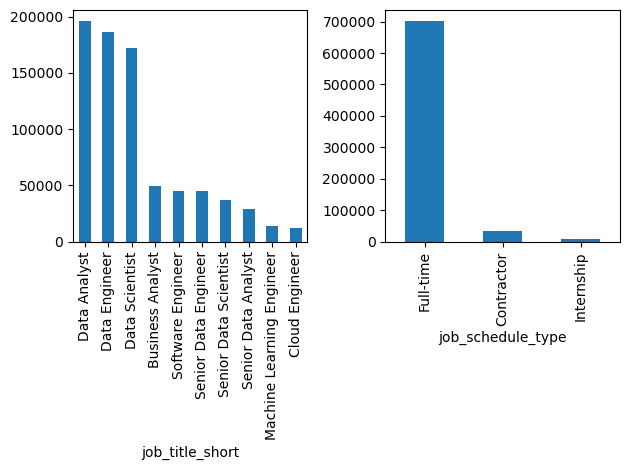

In [2]:
#create a subplot 
fig, ax = plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[1])

fig.tight_layout() #helps separate the different plots


Plot the different counts of the skills required per role i.e. data analysts, data engineers and data scientists on the same subplot

In [3]:
df['job_title_short'].value_counts().head(3)

job_title_short
Data Analyst      196075
Data Engineer     186241
Data Scientist    172286
Name: count, dtype: int64

In [4]:
#ORGANIZE DATA ANALYST INFORMATION
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month
df_DA_exploded = df_DA.explode('job_skills')
df_DA_pivot = df_DA_exploded.pivot_table(
    index='job_posted_month_no', 
    columns='job_skills', 
    aggfunc='size',
    fill_value=0 )#fills the NaN values with zero
#we need to create a row called total that sums up the values in the newly created pivot columns
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot.loc['Total'].sort_values(ascending=False).index

df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_pivot = df_DA_pivot.drop('Total')

In [5]:
#ORGANIZE DATA ENGINEER INFORMATION
df_DE = df[df['job_title_short'] == 'Data Engineer'].copy()
df_DE['job_posted_month_no'] = df_DE['job_posted_date'].dt.month
df_DE_exploded = df_DE.explode('job_skills')
df_DE_pivot = df_DE_exploded.pivot_table(
    index='job_posted_month_no', 
    columns='job_skills', 
    aggfunc='size',
    fill_value=0 )#fills the NaN values with zero
#we need to create a row called total that sums up the values in the newly created pivot columns
df_DE_pivot.loc['Total'] = df_DE_pivot.sum()
df_DE_pivot.loc['Total'].sort_values(ascending=False).index

df_DE_pivot[df_DE_pivot.loc['Total'].sort_values(ascending=False).index]
df_DE_pivot = df_DE_pivot[df_DE_pivot.loc['Total'].sort_values(ascending=False).index]

df_DE_pivot = df_DE_pivot.drop('Total')

In [6]:
#ORGANIZE DATA SCIENTIST INFORMATION
df_DS = df[df['job_title_short'] == 'Data Scientist'].copy()
df_DS['job_posted_month_no'] = df_DS['job_posted_date'].dt.month
df_DS_exploded = df_DS.explode('job_skills')
df_DS_pivot = df_DS_exploded.pivot_table(
    index='job_posted_month_no', 
    columns='job_skills', 
    aggfunc='size',
    fill_value=0 )#fills the NaN values with zero
#we need to create a row called total that sums up the values in the newly created pivot columns
df_DS_pivot.loc['Total'] = df_DS_pivot.sum()
df_DS_pivot.loc['Total'].sort_values(ascending=False).index

df_DS_pivot[df_DS_pivot.loc['Total'].sort_values(ascending=False).index]
df_DS_pivot = df_DS_pivot[df_DS_pivot.loc['Total'].sort_values(ascending=False).index]

df_DS_pivot = df_DS_pivot.drop('Total')

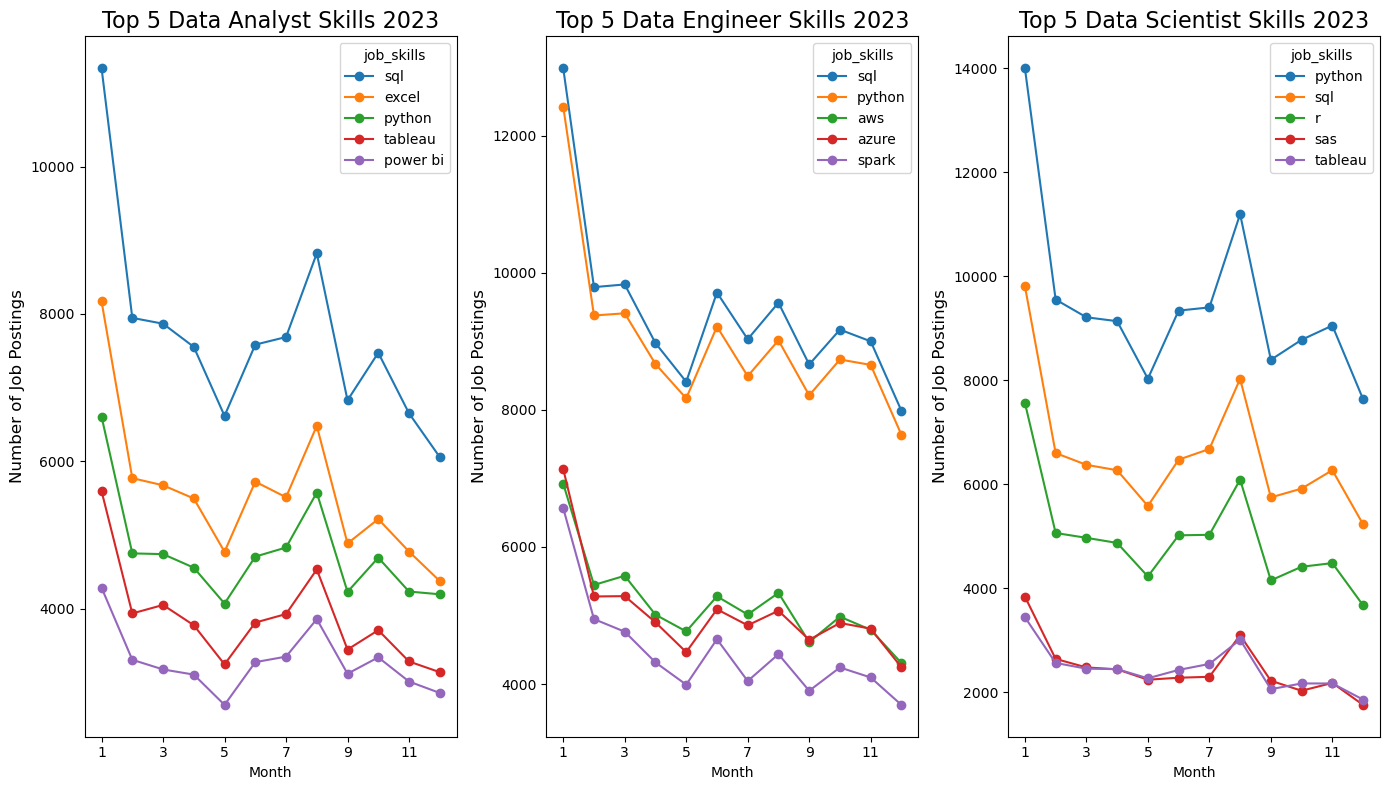

In [7]:
#create a subplot 
fig, ax = plt.subplots(1,3,figsize=(18, 6))

df_DA_pivot.iloc[:, :5].plot(kind='line', marker='o', figsize=(14, 8), ax = ax[0])
ax[0].set_title('Top 5 Data Analyst Skills 2023', fontsize=16)
ax[0].set_ylabel('Number of Job Postings', fontsize=12)
ax[0].set_xlabel('Month')

df_DE_pivot.iloc[:, :5].plot(kind='line', marker='o', figsize=(14, 8), ax = ax[1])
ax[1].set_title('Top 5 Data Engineer Skills 2023', fontsize=16)
ax[1].set_ylabel('Number of Job Postings', fontsize=12)
ax[1].set_xlabel('Month')

df_DS_pivot.iloc[:, :5].plot(kind='line', marker='o', figsize=(14, 8), ax = ax[2])
ax[2].set_title('Top 5 Data Scientist Skills 2023', fontsize=16)
ax[2].set_ylabel('Number of Job Postings', fontsize=12)
ax[2].set_xlabel('Month')

fig.tight_layout() #helps separate the different plots
plt.show()

In [8]:
#A different approach

df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


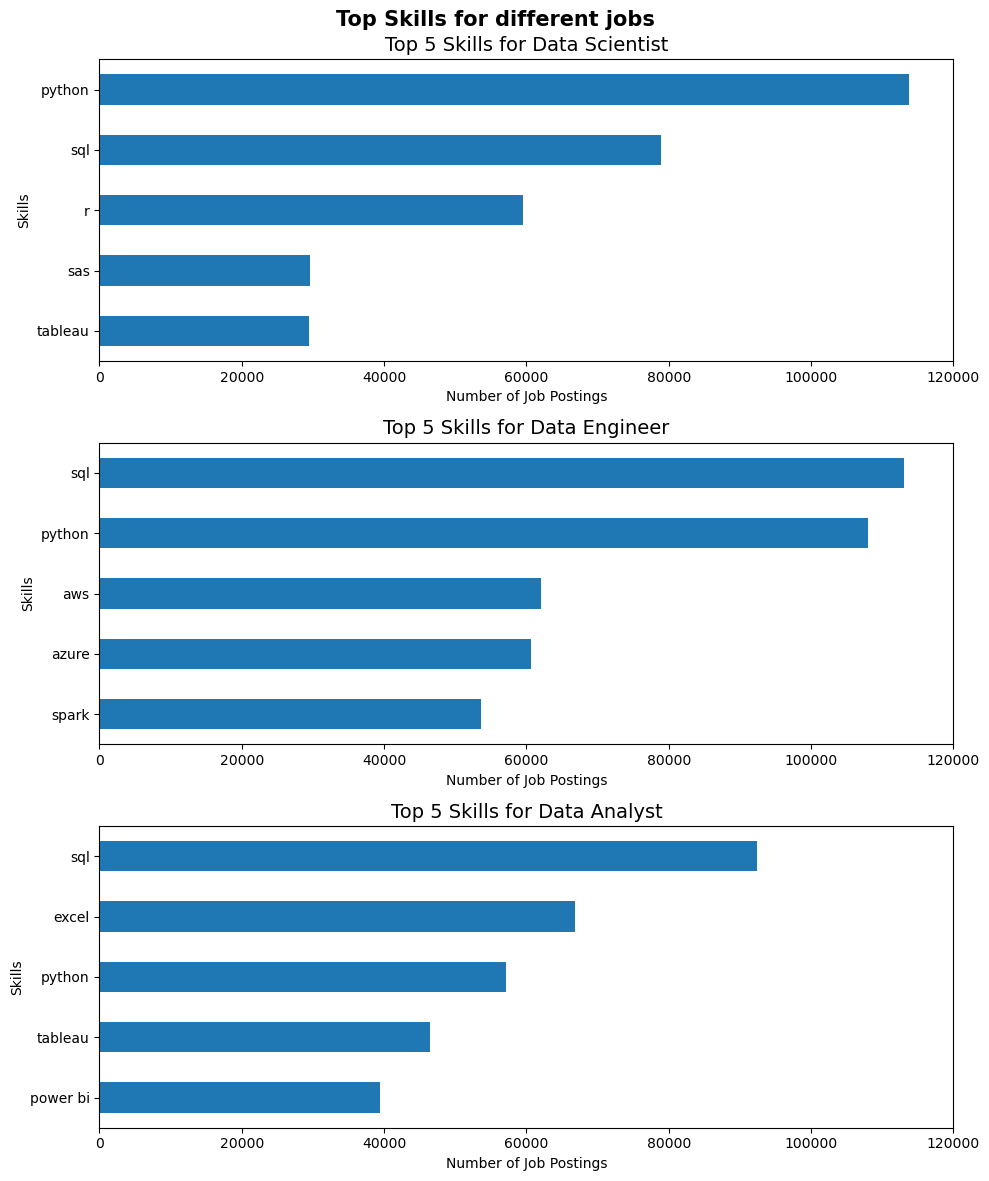

In [ ]:
# Create list of job titles
job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']

# Create subplots (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, job_title in enumerate(job_titles):
    # Filter for current job title and get top 5 skills
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    
    # Plot horizontal bar chart with no legend
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=axes[i], legend=False)
    
    # Invert y-axis so highest skill is at the top
    axes[i].invert_yaxis()
    
    # Set titles and labels
    axes[i].set_title(f'Top 5 Skills for {job_title}', fontsize=14)
    axes[i].set_xlabel('Number of Job Postings', fontsize=10)
    axes[i].set_ylabel('Skills', fontsize=10)
    axes[i].set_xlim(0, 120000)

# Adjust layout and display
fig.suptitle('Top Skills for different jobs', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()